In [1]:
import pandas as pd
import numpy as np
import spikeinterface.extractors as se
import spikeinterface.preprocessing as sp
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import numpy as np
import neurokit2 as nk
import tdt
import spikeinterface.extractors as se
import neurokit2 as nk
import matplotlib.pyplot as plt
import numpy as np

c:\Users\sjs93\anaconda3\envs\biopipeline-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

# Define file path
datapath = r"E:\st_resp_1_2_hab_20250806_160914.rec\st_resp_1_2_hab_20250806_160914.rec"

# Load recording
recording = se.read_spikegadgets(datapath, stream_id='ECU')

# Print available channel IDs
channel_ids = recording.get_channel_ids()
print("Available channels:", channel_ids)
# Define respiration channel (ECU_Ain1)
resp_channel = 'ECU_Ain1'

# Get sampling rate
fs = recording.get_sampling_frequency()  
# Extract respiration signal
resp_signal = recording.get_traces(channel_ids=[resp_channel]).flatten()

# Create time array
time = np.arange(len(resp_signal)) / fs  # Convert samples to time (seconds)

# Apply Butterworth filter (fix: use sampling_rate instead of fs)
resp_cleaned = nk.signal_filter(
    resp_signal,
    lowcut=0.01,   # Low cutoff frequency (Hz)
    highcut=20,    # High cutoff frequency (Hz)
    method="butterworth",  # Filtering method
    sampling_rate=fs,  # Correct parameter name
    order=2        # Filter order
)



Available channels: ['ECU_Ain1' 'ECU_Ain2' 'ECU_Ain3' 'ECU_Ain4' 'ECU_Ain5' 'ECU_Ain6'
 'ECU_Ain7' 'ECU_Ain8' 'ECU_Aout1' 'ECU_Aout2' 'ECU_Aout3' 'ECU_Aout4']


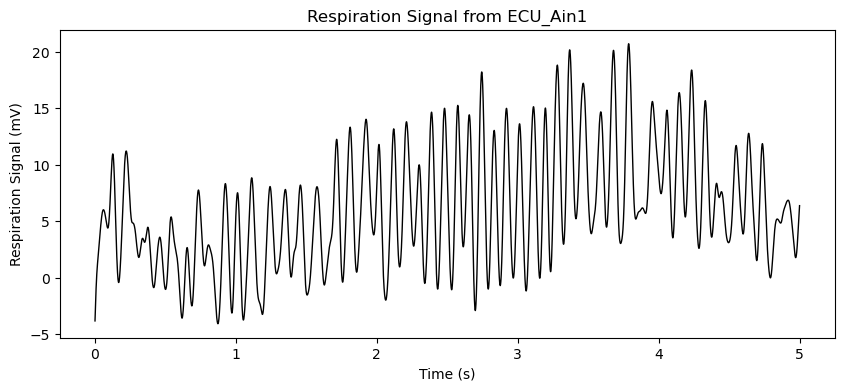

In [7]:
# Define time window (first 10 seconds)
starttime=0
endtime= 5  # seconds
num_samples_start = int(fs * starttime)  # Number of samples for 10 seconds
num_samples_end = int(fs * endtime)
# Slice the first 10 seconds of data
resp_signal_10s = resp_cleaned[num_samples_start:num_samples_end]
time_10s = np.arange(len(resp_signal_10s)) / fs  # Convert to time (s)
# Plot respiration signal
plt.figure(figsize=(10, 4))
plt.plot(time_10s, resp_signal_10s, color='black', linewidth=1)
plt.xlabel("Time (s)")
plt.ylabel("Respiration Signal (mV)")
plt.title(f"Respiration Signal from {resp_channel}")
plt.grid(False)
plt.show()